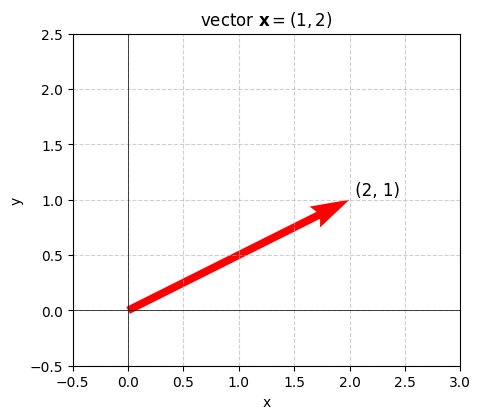

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 我现在有一个二维向量
x = np.array([2, 1])

# 它长这样
fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='r', width=0.02)
ax.set_xlim(-0.5, 3)
ax.set_ylim(-0.5, 2.5)
ax.axhline(0, color='black', linewidth=0.5)  # x轴
ax.axvline(0, color='black', linewidth=0.5)  # y轴
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal')  # 保持 x, y 比例一致，避免箭头变形
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('vector $\\mathbf{x} = (1, 2)$')
ax.text(x[0], x[1], f' ({x[0]}, {x[1]})', fontsize=12, verticalalignment='bottom')

plt.show()

x_proj = [ 2.51645816 -0.51068198  1.06124012]


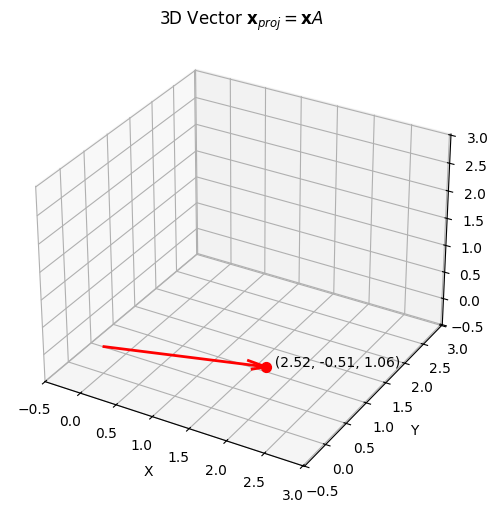

In [19]:
# 我们随机化一个矩阵，将其投影到三维空间
np.random.seed(42)
proj_matrix = np.random.normal(size=(2, 3))

x_proj = np.matmul(x, proj_matrix)
print("x_proj =", x_proj)

# 创建 3D 画布
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 画向量：从原点 (0,0,0) 指向 x_proj
ax.quiver(0, 0, 0, x_proj[0], x_proj[1], x_proj[2],
          arrow_length_ratio=0.1, color='red', linewidth=2)

# 标记终点
ax.scatter(*x_proj, color='red', s=50)
ax.text(x_proj[0], x_proj[1], x_proj[2],
        f'  ({x_proj[0]:.2f}, {x_proj[1]:.2f}, {x_proj[2]:.2f})',
        fontsize=10)

# 设置坐标轴范围（根据实际数据调整）
max_val = max(abs(x_proj))
margin = 0.2 * max_val if max_val > 0 else 1
ax.set_xlim(-margin, max_val + margin)
ax.set_ylim(-margin, max_val + margin)
ax.set_zlim(-margin, max_val + margin)

# 坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Vector $\\mathbf{x}_{proj} = \\mathbf{x} A$')

# 辅助网格
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

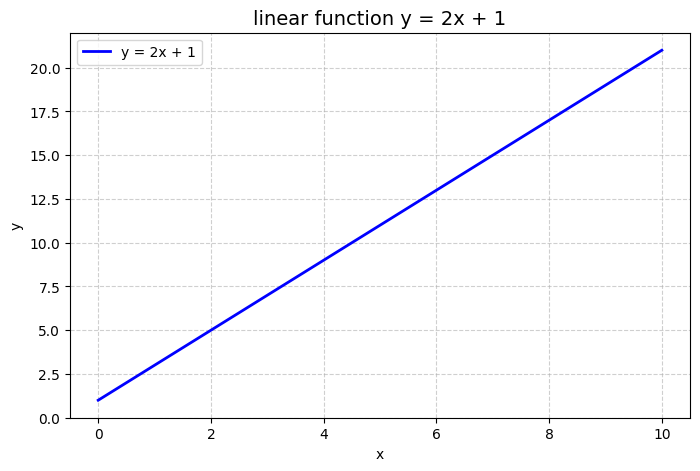

In [20]:
x = np.linspace(0, 10, 1000)
y = 2 * x + 1

# 创建图形
plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', linewidth=2, label='y = 2x + 1')

# 装饰图形
plt.title('linear function y = 2x + 1', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 显示图像
plt.show()

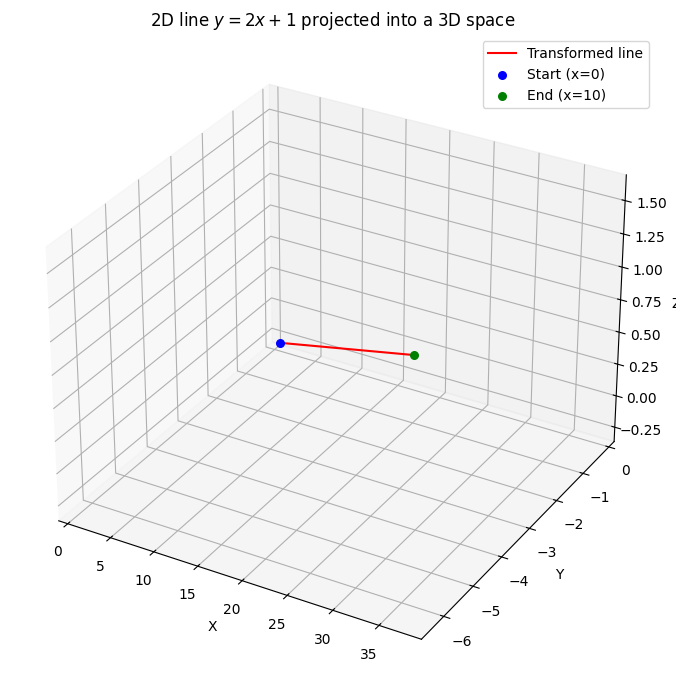

In [21]:
line = np.column_stack((x, y))

line_proj = np.matmul(line, proj_matrix)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(line_proj[:, 0], line_proj[:, 1], line_proj[:, 2],
        color='red', linewidth=1.5, label='Transformed line')

ax.scatter(*line_proj[0, :], color='blue', s=30, label='Start (x=0)')
ax.scatter(*line_proj[-1, :], color='green', s=30, label='End (x=10)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('2D line $y=2x+1$ projected into a 3D space')

ax.legend()
plt.tight_layout()
plt.show()

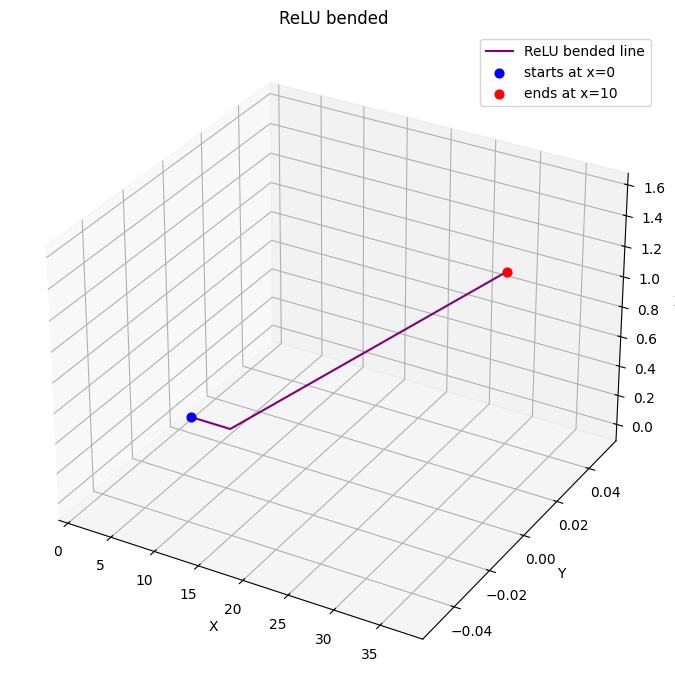

In [31]:
line_proj_bended = np.maximum(line_proj, 0)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(line_proj_bended[:, 0],
        line_proj_bended[:, 1],
        line_proj_bended[:, 2],
        color='purple', linewidth=1.5, label='ReLU bended line')

ax.scatter(*line_proj_bended[0, :], color='blue', s=40, label='starts at x=0')
ax.scatter(*line_proj_bended[-1, :], color='red', s=40, label='ends at x=10')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('ReLU bended')
ax.legend()

plt.tight_layout()
plt.show()

[[1.52302986 0.         0.        ]
 [1.55849306 0.         0.        ]
 [1.59395626 0.         0.        ]
 [1.62941946 0.         0.        ]
 [1.66488266 0.         0.        ]]
[[-0.71239066  0.75376638 -0.04450308]
 [ 0.45181234  1.34510171  0.53233789]
 [ 1.3501879   0.86121137  1.47868574]]
[[0.         1.1480087  0.        ]
 [0.         1.17473967 0.        ]
 [0.         1.20147064 0.        ]
 [0.         1.22820161 0.        ]
 [0.         1.25493258 0.        ]]


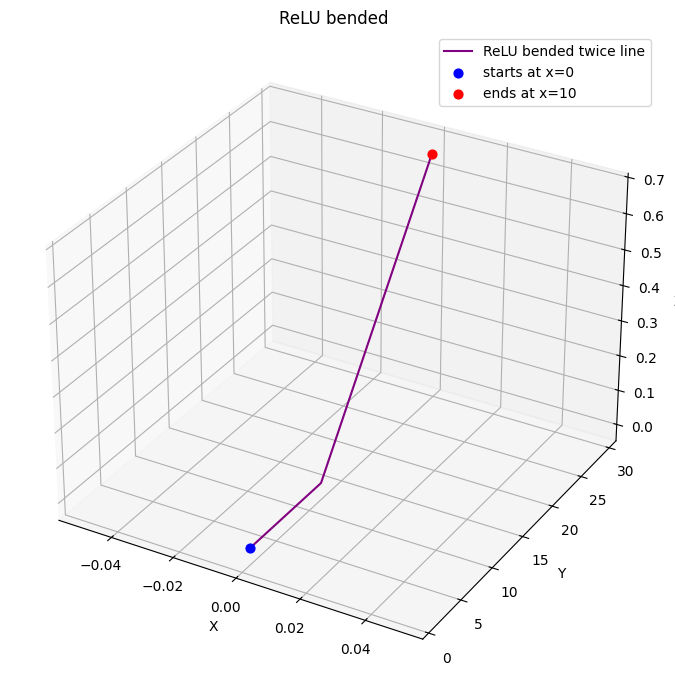

In [46]:
print(line_proj_bended[0:5])

np.random.seed(13)
proj_matrix_second = np.random.normal(size=(3,3))
print(proj_matrix_second[0:5])

line_proj_bended_twice = np.maximum(np.matmul(line_proj_bended, proj_matrix_second), 0)

print(line_proj_bended_twice[0:5])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(line_proj_bended_twice[:, 0],
        line_proj_bended_twice[:, 1],
        line_proj_bended_twice[:, 2],
        color='purple', linewidth=1.5, label='ReLU bended twice line')

ax.scatter(*line_proj_bended_twice[0, :], color='blue', s=40, label='starts at x=0')
ax.scatter(*line_proj_bended_twice[-1, :], color='red', s=40, label='ends at x=10')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('ReLU bended')
ax.legend()

plt.tight_layout()
plt.show()